In [1]:
import src.graphs as graphs
import igraph as ig
import networkx as nx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2

In [ ]:
pd.options.display.float_format = '{:,.4f}'.format
pd.set_option('display.max_columns', None)
plt.rcParams["figure.figsize"] = [10,10]
sns.set(style="whitegrid")

In [4]:
n = graphs.D4K4.as_undirected().simplify(loops=True).to_networkx()

In [5]:
nx.diameter(n)

4

In [6]:
def draw_chain_graph(n, pos=None):
    if pos is None:
        pos = nx.spring_layout(n, seed=42)
    nx.draw(n,
        with_labels=True,
        node_color=['orange' if i < 20 else 'green' if i < 40 else 'lightblue' for i in n.nodes()],
        node_size=100,
        font_size=7,
        font_color='black',
        edge_color='gray',
        pos=pos,
    )

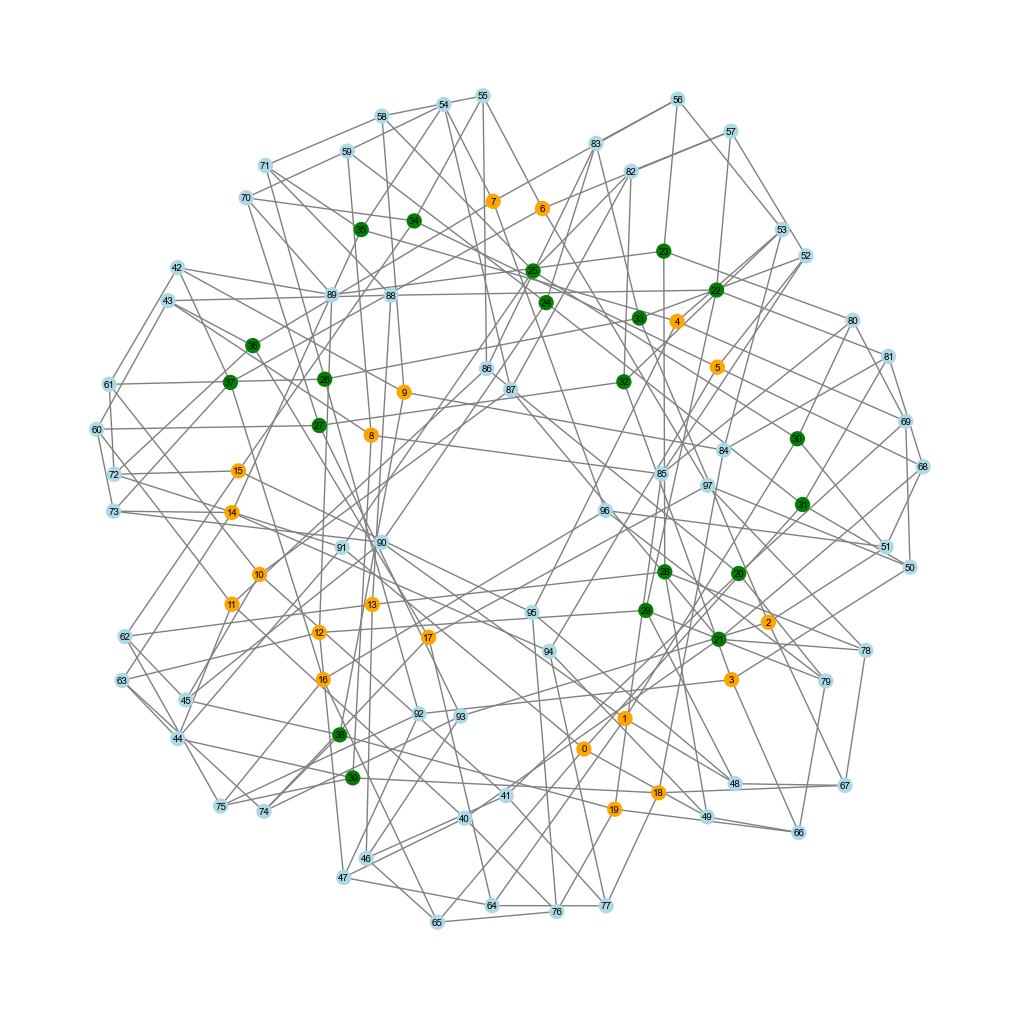

In [7]:
draw_chain_graph(n, pos=nx.kamada_kawai_layout(n))

The spectral layout (based on the laplacian eigenvector) highlights the
symmetric structure of the graph:

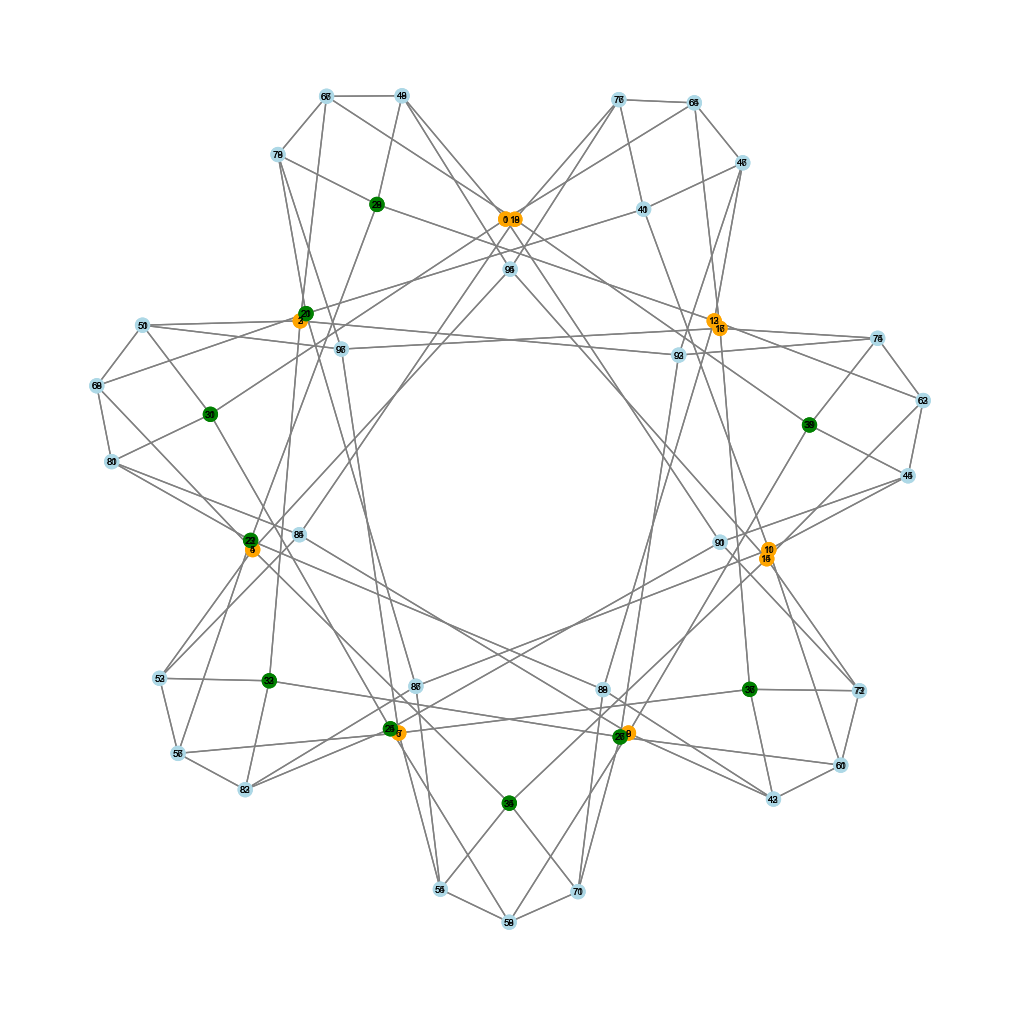

In [8]:
draw_chain_graph(n, pos=nx.spectral_layout(n, scale=3, center=(0,0)))

In [9]:
l = nx.spectral_layout(n, center=(0,0), scale=10)
l

{0: array([-0.09876159,  6.24721992]),
 1: array([-0.09876159,  6.24721992]),
 2: array([-4.94523968,  3.89507791]),
 3: array([-4.94523968,  3.89507791]),
 4: array([-6.06785142, -1.39013721]),
 5: array([-6.06785142, -1.39013721]),
 6: array([-2.62124728, -5.62855066]),
 7: array([-2.62124728, -5.62855066]),
 8: array([ 2.79920952, -5.62855066]),
 9: array([ 2.79920952, -5.62855066]),
 10: array([ 6.11180446, -1.39013721]),
 11: array([ 6.11180446, -1.39013721]),
 12: array([4.82208599, 3.89507791]),
 13: array([4.82208599, 3.89507791]),
 14: array([ 6.06296515, -1.60171838]),
 15: array([ 6.06296515, -1.60171838]),
 16: array([4.95768039, 3.72235488]),
 17: array([4.95768039, 3.72235488]),
 18: array([0.11916117, 6.24341899]),
 19: array([0.11916117, 6.24341899]),
 20: array([-4.80908884,  4.06306126]),
 21: array([-4.80908884,  4.06306126]),
 22: array([-6.11599686, -1.17686447]),
 23: array([-6.11599686, -1.17686447]),
 24: array([-2.81743451, -5.53058725]),
 25: array([-2.8174345

In [10]:
import cmath

def cart2polar(z):
    x,y = z
    return (cmath.polar(complex(x,y)))

def polar2cart(p):
    rho, phi = p
    z = rho * cmath.exp(1j * phi)
    return (z.real, z.imag)

In [11]:
cl = { k: complex(*v) for k,v in l.items() }
# move nodes at the same coordinates apart:
cl2 = { k: complex(*x) * (1 + ((k % 2) + 1) * 0.1) for k,x in l.items() }

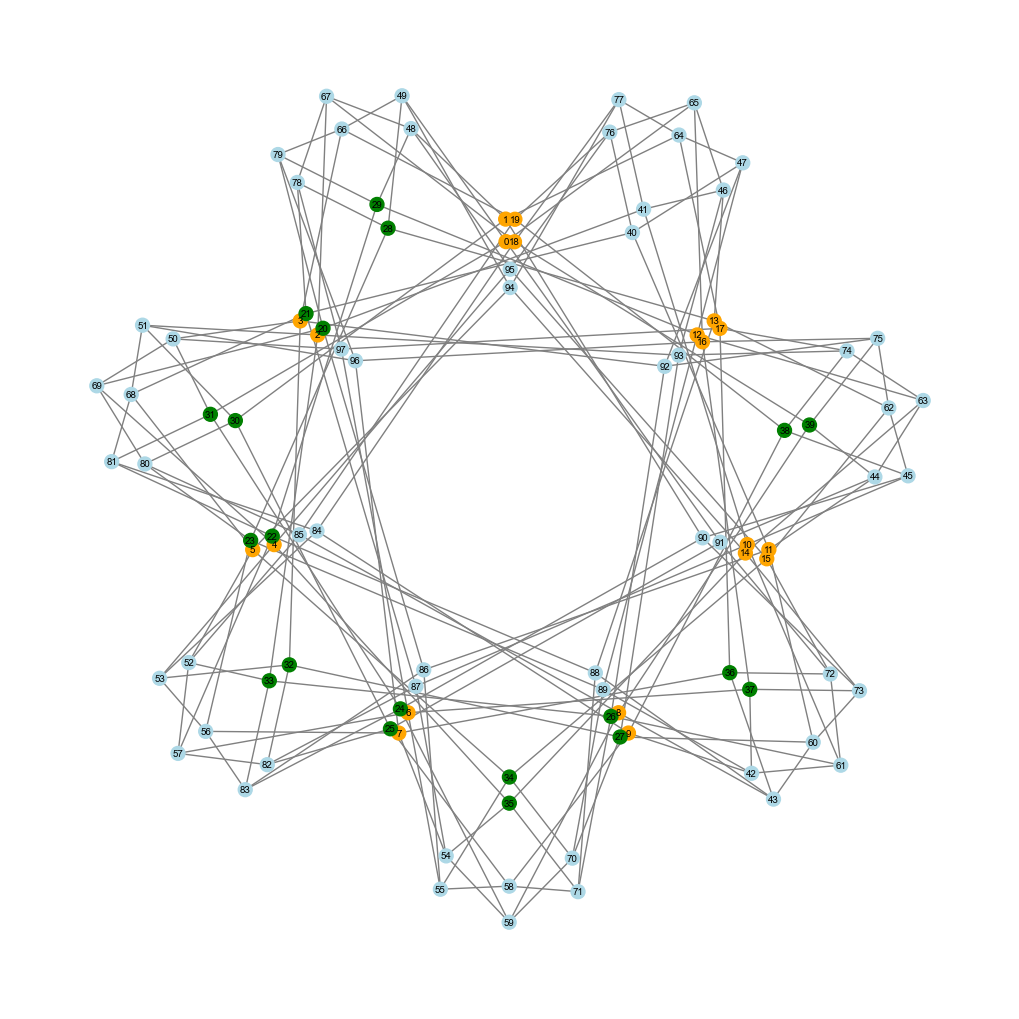

In [12]:
draw_chain_graph(n, pos={ k: [v.real, v.imag] for k,v in cl2.items() })

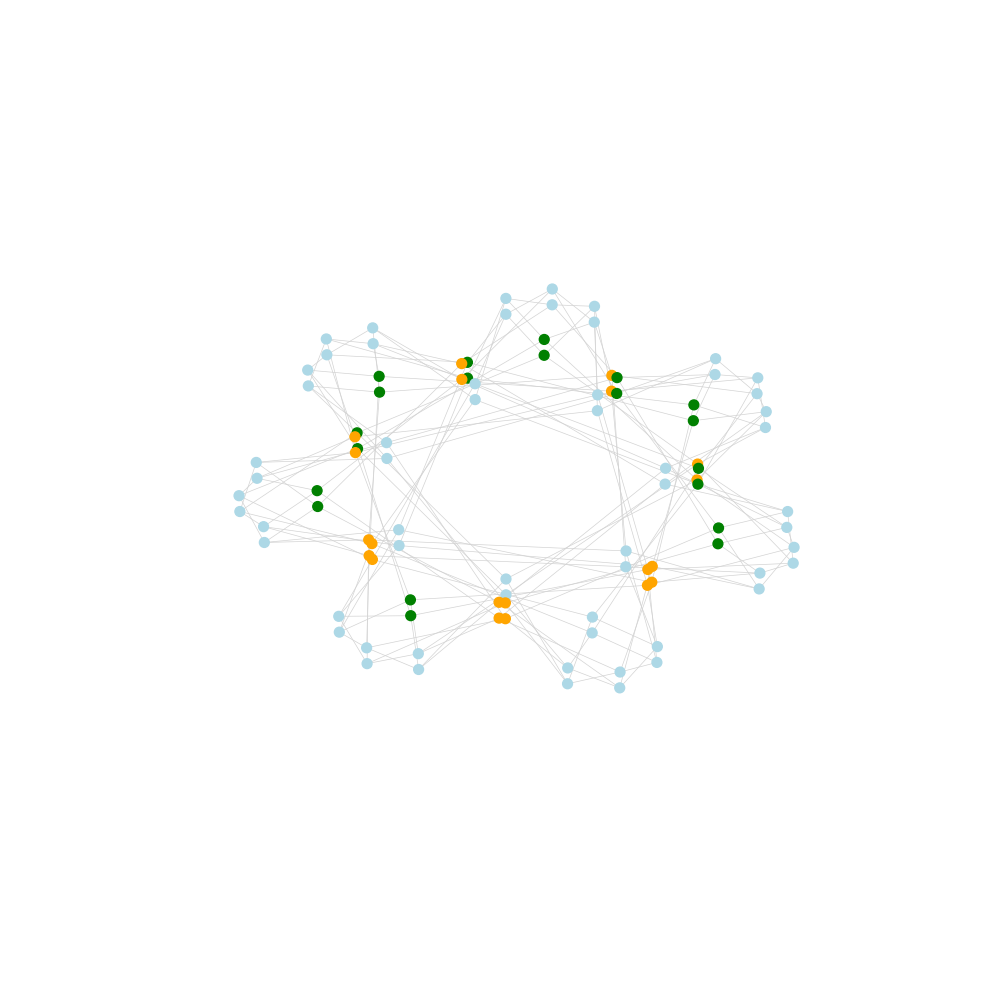

In [93]:
plt.rcParams["figure.figsize"] = [10, 10]
pos = { k: [x, y, (k % 2) * 0.2] for k,[x,y] in l.items() }
nodes = np.array([pos[v] for v in n])
edges = np.array([(pos[u], pos[v]) for u, v in n.edges()])

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

def init():
    for vizedge in edges:
        ax.plot(*vizedge.T, alpha=1, color="lightgray", linewidth=0.5, zorder=1)
    ax.scatter(
        *nodes.T,
        alpha=1,
        s=50,
        zorder=2,
        # color=["orange" if i % 2 == 0 else "green" for i in n.nodes()]
        color=['orange' if i < 20 else 'green' if i < 40 else 'lightblue' for i in n.nodes()],
    )
    ax.grid(False)
    ax.set_axis_off()
    # for dim in (ax.xaxis, ax.yaxis, ax.zaxis):
    #     dim.set_ticks([])
    ax.view_init(45, 45)
    ax.set_zlim(-2, 2)
    plt.tight_layout()
    return

# from matplotlib import animation
# %matplotlib widget
# def _frame_update(index):
#     ax.view_init(index * 0.2, index * 0.5)
#     return
# 
# ani = animation.FuncAnimation(
#     fig,
#     _frame_update,
#     init_func=init,
#     interval=10,
#     cache_frame_data=False,
#     frames=100,
# )

init()
plt.show()


In [ ]:
# move nodes at the same coordinate to different z coordinates:
cl3d = { k: [x, y, (k % 2)] for k,[x,y] in l.items() }

nx.draw(n,
    with_labels=True,
    node_color=['orange' if i < 20 else 'green' if i < 40 else 'lightblue' for i in n.nodes()],
    node_size=100,
    font_size=7,
    font_color='black',
    edge_color='gray',
    pos=cl3d
)

# Shortest Paths

In [9]:
m = pd.DataFrame(dict(nx.shortest_path_length(n)), dtype=int).astype('Int64')
m

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97
0,0,4,4,3,4,3,4,4,4,4,4,3,4,3,3,3,2,4,4,3,4,4,3,3,2,2,4,4,2,4,3,1,4,4,4,4,3,3,4,3,3,3,4,4,2,4,2,4,4,1,2,4,4,4,4,4,4,4,3,3,4,3,4,3,4,1,2,4,3,3,4,4,2,4,4,3,2,3,3,3,4,2,3,3,3,4,4,4,4,4,3,1,4,3,2,3,3,3
31,1,3,4,2,3,3,3,4,3,3,4,4,4,4,4,4,3,3,3,4,3,3,2,4,1,3,4,4,3,3,4,0,3,3,4,4,4,4,4,4,4,4,4,4,3,3,3,4,4,2,1,3,4,3,3,4,3,3,4,2,4,4,4,4,4,2,3,4,2,2,3,4,3,3,4,4,3,4,3,4,3,1,4,2,2,4,3,4,3,4,2,2,3,4,3,4,4,2
49,1,4,4,2,4,2,4,4,4,4,4,4,4,2,2,4,3,4,3,2,3,3,4,2,3,3,4,4,1,3,4,2,3,4,3,3,4,4,3,4,4,3,4,4,3,4,3,4,4,0,3,4,3,4,4,4,3,4,4,4,4,4,3,3,3,2,1,3,3,4,4,4,3,3,4,4,3,2,2,2,3,3,4,4,4,3,4,4,3,3,4,2,3,4,1,4,3,3
65,1,4,3,4,3,4,3,3,4,4,3,3,4,2,4,3,1,4,4,2,3,3,4,4,3,3,4,3,3,4,4,2,4,4,4,4,4,2,3,3,2,2,3,4,3,4,1,3,3,2,3,3,4,4,4,4,4,4,4,4,4,4,3,4,4,0,3,4,4,4,4,4,3,3,3,2,1,3,4,3,4,3,4,4,4,3,4,4,3,4,4,2,3,2,3,2,2,4
91,1,3,4,4,4,4,4,3,3,3,3,2,3,4,3,2,3,3,3,4,4,4,4,4,3,1,3,4,3,4,2,2,3,4,3,4,2,4,4,2,3,4,3,3,1,4,3,4,4,2,3,3,4,4,4,3,4,3,2,4,3,2,3,2,4,2,3,4,4,4,4,3,1,4,3,3,3,4,4,4,3,3,2,4,4,4,3,3,4,4,4,0,4,4,3,3,4,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,4,4,4,3,3,3,3,2,3,4,1,3,4,4,3,4,4,4,4,4,3,1,3,4,3,2,3,3,3,4,3,4,2,4,4,2,3,4,3,4,2,2,3,4,4,2,3,3,4,4,4,3,3,3,1,4,3,2,3,2,4,2,3,4,4,4,4,3,2,4,3,3,3,4,4,4,3,3,2,4,4,3,1,4,4,4,4,0,4,4,3,3,4,4,4,4,3,3
60,4,3,3,3,4,4,3,3,2,4,4,1,4,3,2,4,3,3,4,4,3,3,3,4,3,4,4,1,4,4,4,4,2,4,3,3,2,2,4,3,2,4,3,1,2,3,3,3,4,4,4,4,4,3,4,3,4,4,4,3,0,4,4,3,4,4,4,4,4,4,2,3,3,1,3,4,3,4,4,4,4,4,3,3,4,3,2,4,2,3,2,3,4,2,3,4,4,4
12,4,3,4,3,4,4,4,4,4,3,4,3,0,4,2,4,4,3,4,4,3,3,2,2,4,4,3,3,3,1,4,4,4,4,3,3,4,3,3,3,2,4,2,4,2,4,4,1,2,4,4,4,4,4,4,4,3,3,4,3,4,3,4,1,2,4,3,3,4,4,2,4,4,3,2,3,3,3,4,2,3,3,4,4,4,4,4,4,3,1,4,3,2,3,3,3,3,4
43,4,4,4,4,4,4,4,2,1,4,4,2,4,2,3,3,4,2,3,3,4,4,2,4,3,4,3,2,3,3,4,4,3,4,4,3,1,3,4,2,3,4,4,0,3,4,3,4,4,4,4,4,3,4,3,4,3,3,3,2,1,3,3,4,3,4,4,4,4,4,3,2,2,2,3,3,4,4,4,4,3,3,4,4,4,2,3,4,1,4,3,3,4,3,4,4,3,3


In [10]:
def pick(m, vertices):
    # limit the matrix to the vertices
    return m.loc[vertices, vertices]

enabled = pick(m, range(0,40))
pacts = pick(m, range(0,20))
evms = pick(m, range(20,40))
all = pick(m, range(0,98))

def flat_values(m):
    a = m.values.flatten()
    return a[a != 0]

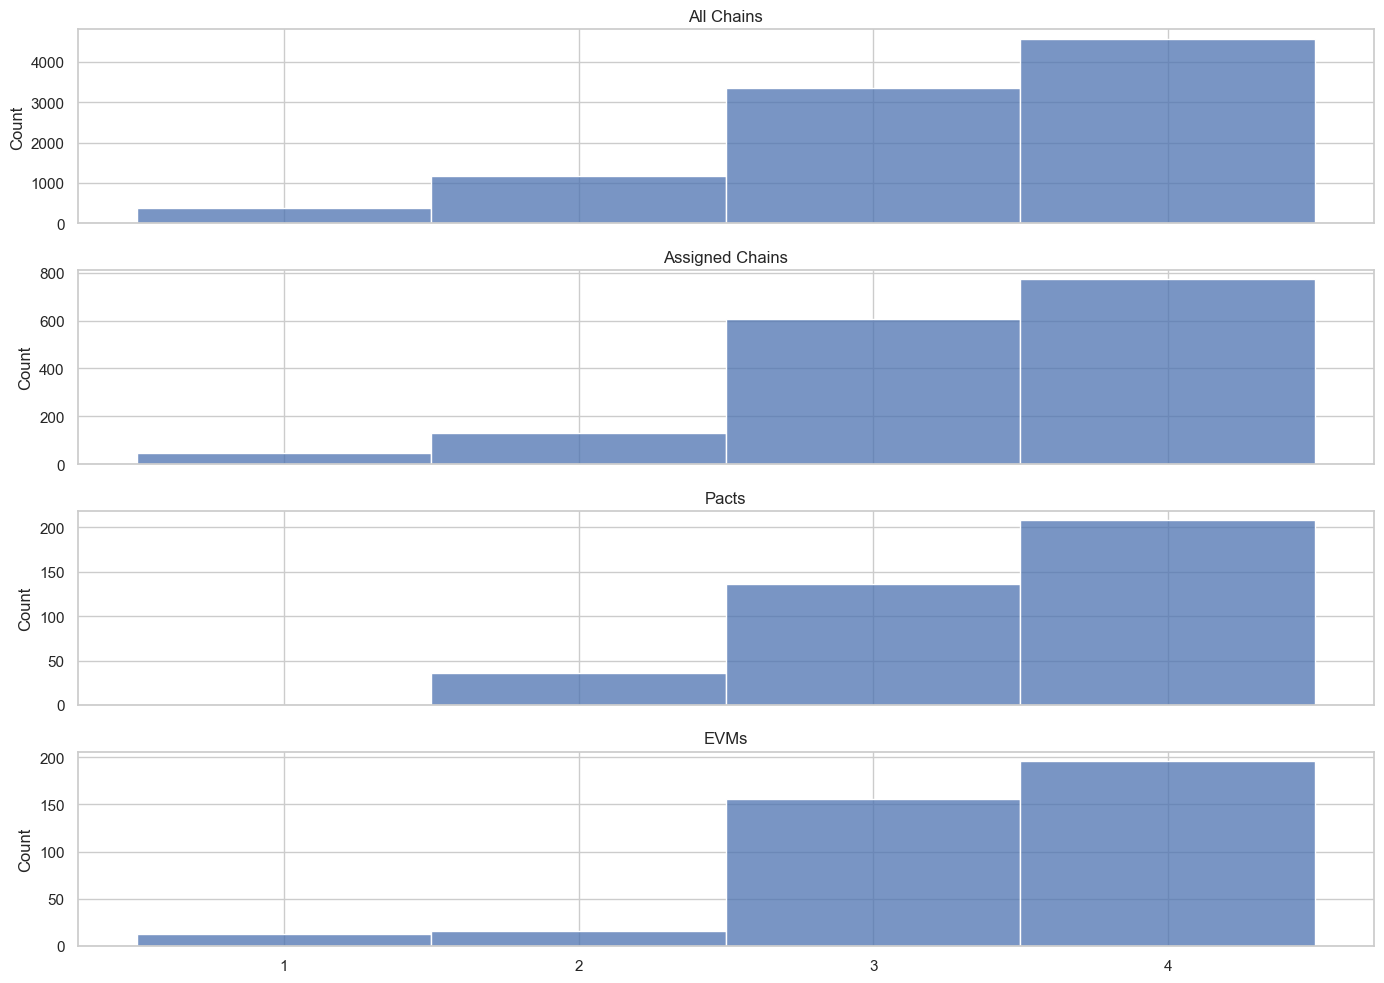

In [11]:
hists = dict({
    'all': flat_values(all),
    'enabled': flat_values(enabled),
    'pacts': flat_values(pacts),
    'evms': flat_values(evms),
})
hists

# sns.histplot(hists, discrete=True, bins=4, stat='density', common_norm=False, multiple='dodge')

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 10), sharex=True)
sns.histplot(flat_values(all), discrete=True, ax=axes[0])
sns.histplot(flat_values(enabled), discrete=True, ax=axes[1])
sns.histplot(flat_values(pacts), discrete=True, ax=axes[2])
sns.histplot(flat_values(evms), discrete=True, ax=axes[3])
axes[3].set_xticks([1, 2, 3, 4])
axes[0].set_title('All Chains')
axes[1].set_title('Assigned Chains')
axes[2].set_title('Pacts')
axes[3].set_title('EVMs')
plt.tight_layout()
plt.show()

In [12]:
# compute mean, median, min, max, and std for [all, pacts, evms] and store the results in a dataframe
pd.DataFrame({
    'all': [all.mean().mean(), all.median().median(), all.min().min(), all.max().max(), all.std().std()],
    'enabled': [enabled.mean().mean(), enabled.median().median(), enabled.min().min(), enabled.max().max(), enabled.std().std()],
    'pacts': [pacts.mean().mean(), pacts.median().median(), pacts.min().min(), pacts.max().max(), pacts.std().std()],
    'evms': [evms.mean().mean(), evms.median().median(), evms.min().min(), evms.max().max(), evms.std().std()]
}, index=['mean', 'median', 'min', 'max', 'std'])


,all,enabled,pacts,evms
mean,3.2420,3.2650,3.2800,3.2400
median,3.0000,3.0000,4.0000,3.5000
min,0.0000,0.0000,0.0000,0.0000
max,4.0000,4.0000,4.0000,4.0000
std,0.0035,0.0298,0.0265,0.0731


# Minimal Dominating Sets

It would be nice to indentify the mimum set of chains that a contract needs to
be deployed to such that each other chain is at most one step away.

In a graph where all chains are assigned almost each set is close the a minimum
dominating set.

Intuitively, this makes sense since chain graphs are expander graphs for which
expansion is uniform with respect to the choice of node subsets.

However, when a larger number (less than a half) of chains is unassigned, the
subgraph or assigned chains is usually has many components. Thus this subgraph
is not an expander graph and and a minum dominating set is accordingly large.

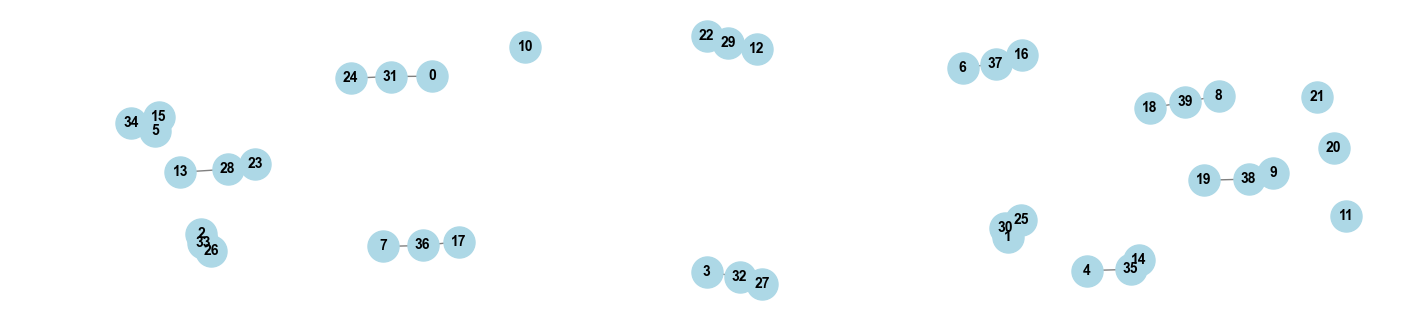

In [ ]:
assigned = n.subgraph(range(0,40))
nx.draw(assigned, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_color='black', font_weight='bold', edge_color='gray')

Weighted minum dominating sets:

This calcuates the (approximate) number of chains from of the respective categroy
that are needed to cover *all* chains in the graph.

In [32]:
for x in n.nodes():
    n.nodes[x]["pact"] = 1 if x < 20 else 100
    n.nodes[x]["evm"] = 1 if x >= 20 and x < 40 else 100
    n.nodes[x]["assigned"] = 1 if x < 40 else 100

pd.DataFrame({
    "all": len(nx.approximation.min_weighted_dominating_set(n)),
    "assigned": len(nx.approximation.min_weighted_dominating_set(n, weight="assigned")),
    "evm": len(nx.approximation.min_weighted_dominating_set(n, weight="evm")),
    "pact": len(nx.approximation.min_weighted_dominating_set(n, weight="pact"))
},
    index=["min_weighted_dominating_set"]
).T

,min_weighted_dominating_set
all,28
assigned,28
evm,34
pact,28
